# Assignment 1: EDA & Data Description of Fashion-MNIST

**This notebook**
- Serves as **Part 1: Problem and Data Description** for the report.
- Covers **Dataset description and EDA** for Assignment 1.
- Contributes to the **Problem & data understanding (15%)** criterion.

Fashion-MNIST is the dataset used here. Each 28 × 28 grayscale image has one of ten clothing labels.

## 0. Setup

Import the tools needed to read arrays and explore images.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from threadpoolctl import threadpool_limits

SEED = 42
NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.Series({'Python': sys.version.split()[0], 'NumPy': np.__version__,
           'pandas': pd.__version__, 'Matplotlib': matplotlib.__version__,
           'scikit-learn': sklearn.__version__}, name='Version').to_frame()

,Version
Python,3.12.13
NumPy,2.5.3
pandas,3.0.5
Matplotlib,3.11.2
scikit-learn,1.9.1


**Observation and comment**

The table records the environment used for these outputs. All figures below are static, so they remain visible when the notebook is opened without a running kernel.

## 1. Read the dataset

Read the official image and label arrays. IDX image headers occupy 16 bytes; label headers occupy 8 bytes.

In [2]:
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == 'Assignment1' else ROOT
RAW = ROOT / 'data' / 'FashionMNIST' / 'raw'
X = np.fromfile(RAW / 'train-images-idx3-ubyte', dtype=np.uint8, offset=16).reshape(-1, 28, 28)
y = np.fromfile(RAW / 'train-labels-idx1-ubyte', dtype=np.uint8, offset=8)
X_test = np.fromfile(RAW / 't10k-images-idx3-ubyte', dtype=np.uint8, offset=16).reshape(-1, 28, 28)
y_test = np.fromfile(RAW / 't10k-labels-idx1-ubyte', dtype=np.uint8, offset=8)
pd.DataFrame([
    [name, images.shape, labels.shape, str(images.dtype), images.min(), images.max()]
    for name, images, labels in [('Original train', X, y), ('Official test', X_test, y_test)]
], columns=['Set', 'Image shape', 'Label shape', 'Pixel dtype', 'Min', 'Max'])

,Set,Image shape,Label shape,Pixel dtype,Min,Max
0,Original train,"(60000, 28, 28)","(60000,)",uint8,0,255
1,Official test,"(10000, 28, 28)","(10000,)",uint8,0,255


**Observation and comment**

There are 60,000 original training images and 10,000 official test images. Each image is 28 × 28 with one grayscale channel, stored as unsigned integers from 0 to 255. Image and label counts match in both sets; the image arrays have no explicit channel dimension.

In [3]:
files = [RAW / name for name in ["train-images-idx3-ubyte", "train-labels-idx1-ubyte",
                                  "t10k-images-idx3-ubyte", "t10k-labels-idx1-ubyte"]]
storage = pd.DataFrame({"File": [path.name for path in files],
                        "Bytes": [path.stat().st_size for path in files]})
storage["MiB"] = storage["Bytes"] / 1024 ** 2
storage.loc[len(storage)] = ["Total", storage["Bytes"].sum(), storage["MiB"].sum()]
storage.round(3)

,File,Bytes,MiB
0,train-images-idx3-ubyte,47040016,44.861
1,train-labels-idx1-ubyte,60008,0.057
2,t10k-images-idx3-ubyte,7840016,7.477
3,t10k-labels-idx1-ubyte,10008,0.010
4,Total,54950048,52.404


**Observation and comment**

The four uncompressed IDX files occupy 54,950,048 bytes (52.404 MiB) on disk, including their headers. Images store one unsigned byte per pixel; labels store one unsigned byte per image. The downloaded `.gz` files are compressed copies, while the arrays above read the uncompressed files directly.

## 2. Define the train and validation subsets

Reserve 10% of the original training set for validation. Use only the remaining training images for detailed EDA and fitted transformations.

In [4]:
train_idx, val_idx = train_test_split(
    np.arange(len(y)), test_size=0.10, stratify=y, random_state=SEED)
train_images, train_labels = X[train_idx], y[train_idx]
split_counts = pd.DataFrame({
    'Train': np.bincount(train_labels, minlength=10),
    'Validation': np.bincount(y[val_idx], minlength=10),
    'Official test': np.bincount(y_test, minlength=10)
}, index=pd.Index(NAMES, name='Class'))
split_counts.loc['Total'] = split_counts.sum()
split_counts

,Train,Validation,Official test
Class,,,
T-shirt/top,5400,600,1000
Trouser,5400,600,1000
Pullover,5400,600,1000
Dress,5400,600,1000
Coat,5400,600,1000
Sandal,5400,600,1000
Shirt,5400,600,1000
Sneaker,5400,600,1000
Bag,5400,600,1000


**Observation and comment**

The split contains 54,000 training and 6,000 validation images. Every class contributes 5,400 training and 600 validation examples, so stratification preserves balance. The 10,000 official test images remain separate. Later image galleries and projection samples come from the training subset.

## 3. Look at one image

Display an actual training image at its native resolution. The ID refers to its row in the original training file.

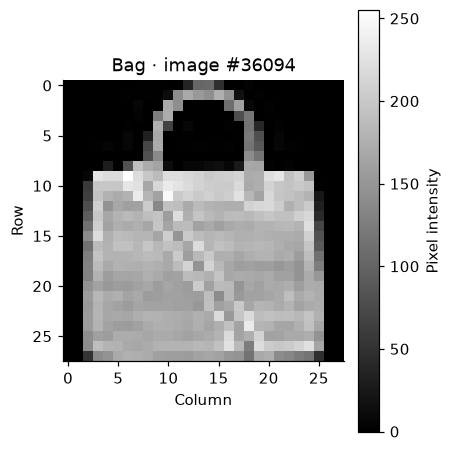

In [5]:
example_id = int(train_idx[0])
example = X[example_id]
fig, ax = plt.subplots(figsize=(4, 4), layout='constrained')
image = ax.imshow(example, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
ax.set(title=f'{NAMES[y[example_id]]} · image #{example_id}', xlabel='Column', ylabel='Row')
fig.colorbar(image, ax=ax, label='Pixel intensity')
plt.show()

**Observation and comment**

The image is made of discrete grayscale pixels: dark values form the background and lighter values describe the item. At this resolution, fine texture and small details are limited. The displayed label identifies a clothing category rather than a particular product.

### 3.1 Pixel values and the flattened input

Zoom into an 8 × 8 patch and show the same image as a vector.

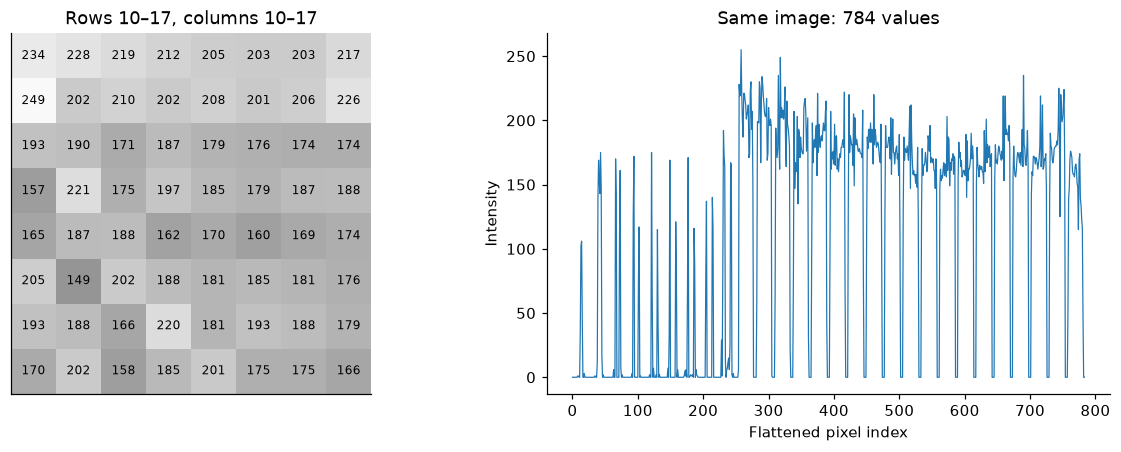

In [6]:
patch = example[10:18, 10:18]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
axes[0].imshow(patch, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
for row, col in np.ndindex(patch.shape):
    axes[0].text(col, row, str(patch[row, col]), ha='center', va='center',
                 color='black' if patch[row, col] > 128 else 'white', fontsize=8)
axes[0].set(title='Rows 10–17, columns 10–17', xticks=[], yticks=[])
axes[1].plot(example.reshape(-1), linewidth=0.8)
axes[1].set(title='Same image: 784 values', xlabel='Flattened pixel index', ylabel='Intensity')
plt.show()

**Observation and comment**

The patch includes intermediate gray values, so the image is not a binary silhouette. Flattening gives 784 features and preserves every pixel value in row-major order. A flat vector does not explicitly encode which pixels were adjacent in two dimensions; no resizing is needed.

## 4. Class distribution and imbalance

Count each class in the two original dataset partitions.

In [7]:
original_counts = pd.DataFrame({
    'Original train': np.bincount(y, minlength=10),
    'Official test': np.bincount(y_test, minlength=10)
}, index=pd.Index(NAMES, name='Class'))
original_counts['Train share (%)'] = original_counts['Original train'] / len(y) * 100
original_counts['Test share (%)'] = original_counts['Official test'] / len(y_test) * 100
original_counts

,Original train,Official test,Train share (%),Test share (%)
Class,,,,
T-shirt/top,6000,1000,10.0,10.0
Trouser,6000,1000,10.0,10.0
Pullover,6000,1000,10.0,10.0
Dress,6000,1000,10.0,10.0
Coat,6000,1000,10.0,10.0
Sandal,6000,1000,10.0,10.0
Shirt,6000,1000,10.0,10.0
Sneaker,6000,1000,10.0,10.0
Bag,6000,1000,10.0,10.0


**Observation and comment**

Every class has 6,000 original training examples and 1,000 official test examples: 10% of each partition. The largest-to-smallest class-count ratio is 1.0 in both sets. There is no class-frequency imbalance to correct, although some categories can still be harder to distinguish visually.

### 4.1 Visual comparison of class counts

Show the original class counts side by side.

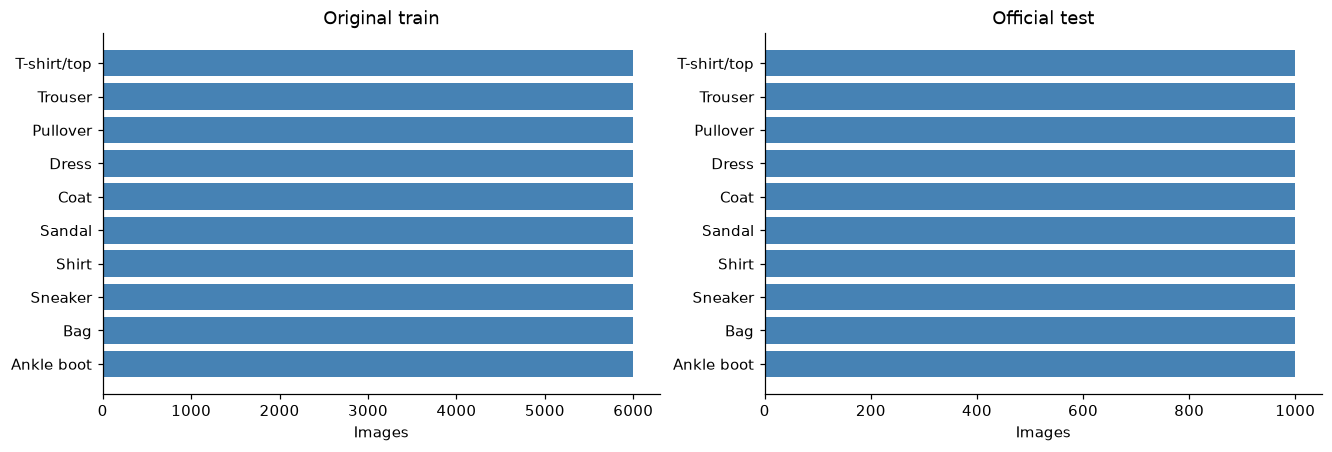

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
for ax, column in zip(axes, ['Original train', 'Official test']):
    ax.barh(NAMES, original_counts[column], color='steelblue')
    ax.invert_yaxis()
    ax.set(title=column, xlabel='Images')
plt.show()

**Observation and comment**

The bars have equal length within each partition. The separate axes show different absolute counts, so compare class proportions rather than bar lengths across panels. An unweighted classification loss is a reasonable future baseline; per-class metrics will still be useful.

## 5. Representative training images

Inspect four seeded examples from each class. First, look at T-shirts, trousers, pullovers, dresses and coats.

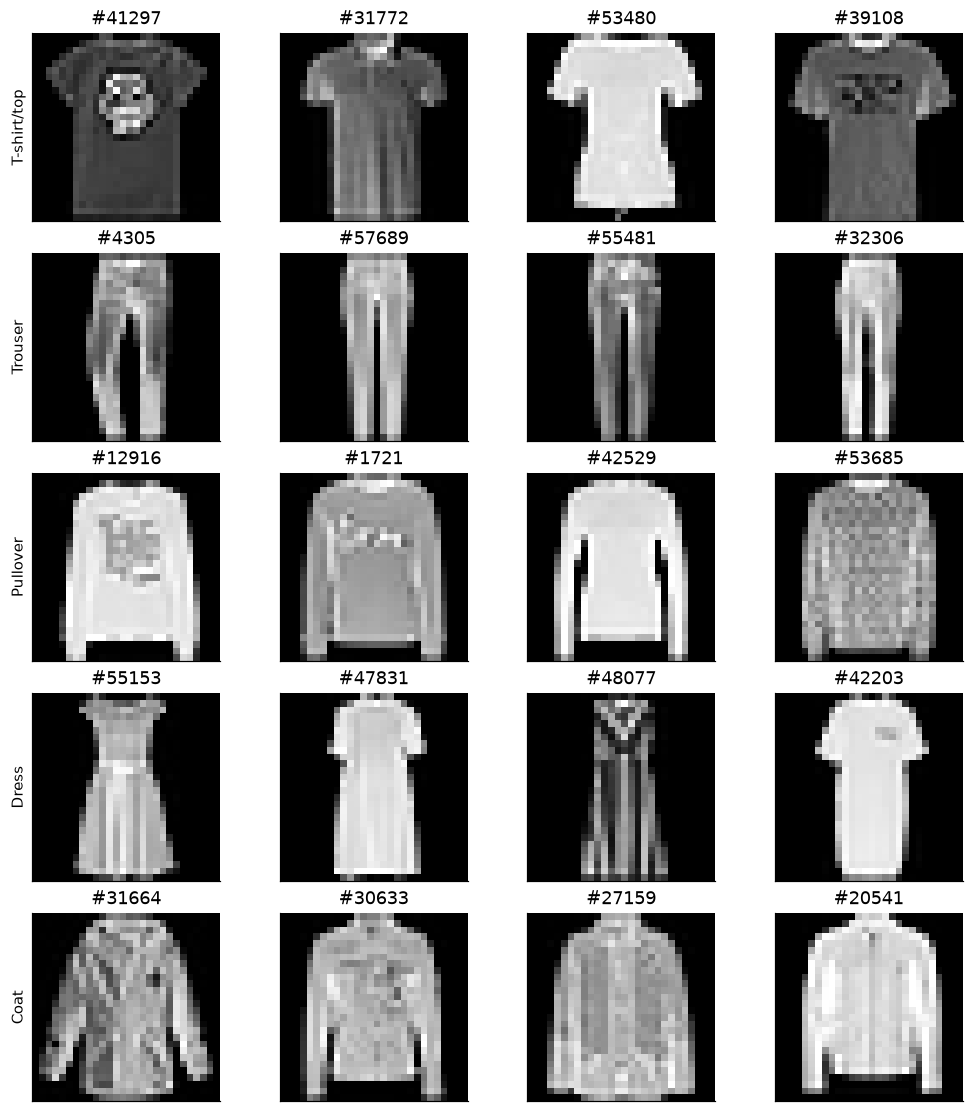

In [9]:
rng = np.random.default_rng(SEED)
gallery_ids = np.array([
    rng.choice(train_idx[y[train_idx] == label], size=4, replace=False)
    for label in range(10)])
fig, axes = plt.subplots(5, 4, figsize=(9, 10), layout='constrained')
for row, label in enumerate(range(5)):
    for ax, index in zip(axes[row], gallery_ids[label]):
        ax.imshow(X[index], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax.set(title=f'#{index}', xticks=[], yticks=[])
    axes[row, 0].set_ylabel(NAMES[label])
plt.show()

**Observation and comment**

Examples within one category differ in brightness, outline and detail. Trousers have a distinctive two-leg silhouette. Pullovers and coats share a torso-and-sleeves structure, while dresses vary in length and shape. Four examples illustrate variation but cannot establish how common each appearance is.

### 5.1 Footwear, shirts and bags

Inspect the remaining five classes using the same sampling rule.

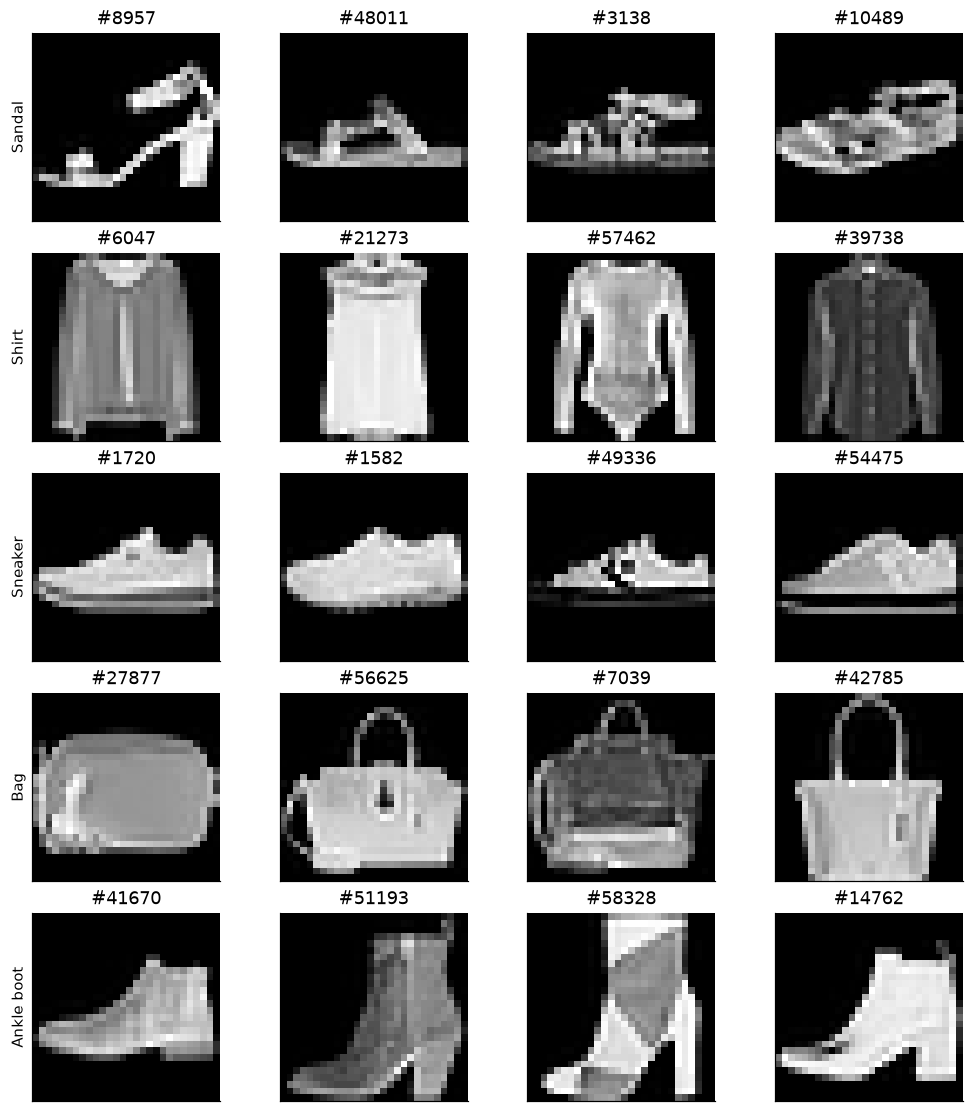

In [10]:
fig, axes = plt.subplots(5, 4, figsize=(9, 10), layout='constrained')
for row, label in enumerate(range(5, 10)):
    for ax, index in zip(axes[row], gallery_ids[label]):
        ax.imshow(X[index], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax.set(title=f'#{index}', xticks=[], yticks=[])
    axes[row, 0].set_ylabel(NAMES[label])
plt.show()

**Observation and comment**

Footwear often has a horizontal silhouette, but sandals, sneakers and ankle boots differ in how much of the foot or ankle they cover. Bags vary in body shape and handle visibility. Shirts share visual elements with several upper-body categories, making their class boundaries worth inspecting more closely.

## 6. Pixel intensity distribution

Count intensities across all 54,000 training images. Use a logarithmic vertical axis so the background spike does not hide the other intensities.

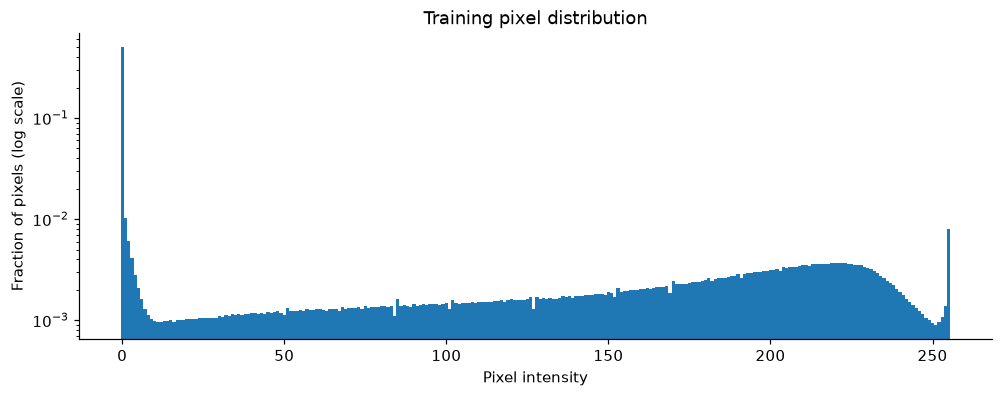

,Value
Zero-valued pixels (%),50.2143
Completely black images,0.0000


In [11]:
pixel_counts = np.bincount(train_images.ravel(), minlength=256)
zero_fraction = pixel_counts[0] / pixel_counts.sum()
fig, ax = plt.subplots(figsize=(9, 3.5), layout='constrained')
ax.bar(np.arange(256), pixel_counts / pixel_counts.sum(), width=1)
ax.set(yscale='log', xlabel='Pixel intensity', ylabel='Fraction of pixels (log scale)',
       title='Training pixel distribution')
plt.show()
pd.Series({'Zero-valued pixels (%)': 100 * zero_fraction,
           'Completely black images': (train_images.max(axis=(1, 2)) == 0).sum()}, name='Value').to_frame()

**Observation and comment**

About half of the training pixels are exactly zero, reflecting the large dark background regions. Other pixels span many intensities, so foreground texture is retained. A high proportion of zero pixels does not mean the corresponding images are empty; the all-black count distinguishes these cases.

### 6.1 Where do pixels vary?

Compare the mean image with variance at each pixel location. Both summaries use intensities scaled to [0, 1].

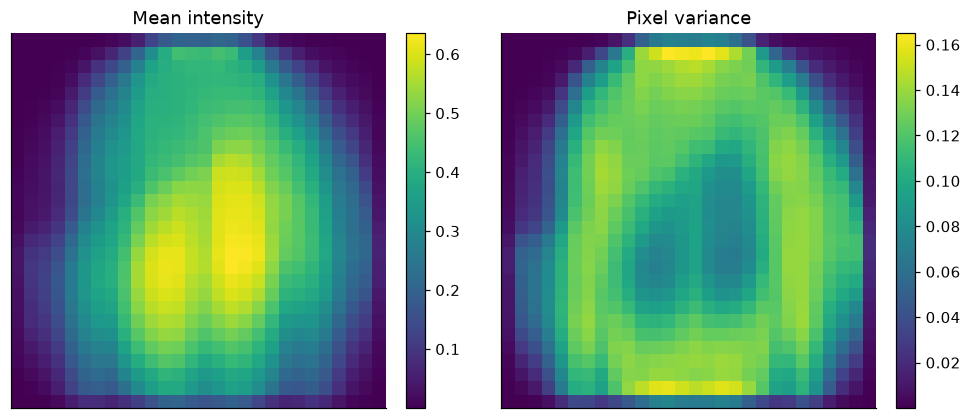

In [12]:
pixels = train_images.astype(np.float32) / 255
pixel_mean = pixels.mean(axis=0)
pixel_variance = pixels.var(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.7), layout='constrained')
for ax, values, title in zip(axes, [pixel_mean, pixel_variance], ['Mean intensity', 'Pixel variance']):
    image = ax.imshow(values, cmap='viridis')
    ax.set(title=title, xticks=[], yticks=[])
    fig.colorbar(image, ax=ax)
plt.show()

**Observation and comment**

The mean image shows where clothing tends to occupy the frame, while variance highlights locations that change across examples. Background corners are comparatively stable. Low variance alone does not establish that a coordinate is useless for distinguishing classes, so these plots do not justify removing pixels.

## 7. Brightness, contrast and foreground coverage

Summarize each image. Brightness is mean intensity, contrast is intensity standard deviation, and foreground means a raw pixel value above 26.

In [13]:
FOREGROUND_THRESHOLD = 26
features = pd.DataFrame({
    'Class': np.array(NAMES)[train_labels],
    'Brightness': pixels.mean(axis=(1, 2)),
    'Contrast': pixels.std(axis=(1, 2)),
    'Coverage': (train_images > FOREGROUND_THRESHOLD).mean(axis=(1, 2))
}, index=train_idx)
features[['Brightness', 'Contrast', 'Coverage']].describe(percentiles=[0.05, 0.5, 0.95]).round(3)

,Brightness,Contrast,Coverage
count,54000.000,54000.000,54000.000
mean,0.286,0.320,0.451
std,0.126,0.078,0.149
min,0.019,0.070,0.038
5%,0.101,0.178,0.214
50%,0.272,0.332,0.458
95%,0.503,0.428,0.673
max,0.752,0.475,0.909


**Observation and comment**

These features describe global appearance, not image correctness. Brightness combines item intensity and occupied area; coverage depends on the chosen threshold. Extreme values should lead to visual inspection before any decision to remove or alter an image.

### 7.1 Compare appearance by class

Show the within-class distributions. Outlier markers are hidden for readability; all images remain included in the boxplot calculations.

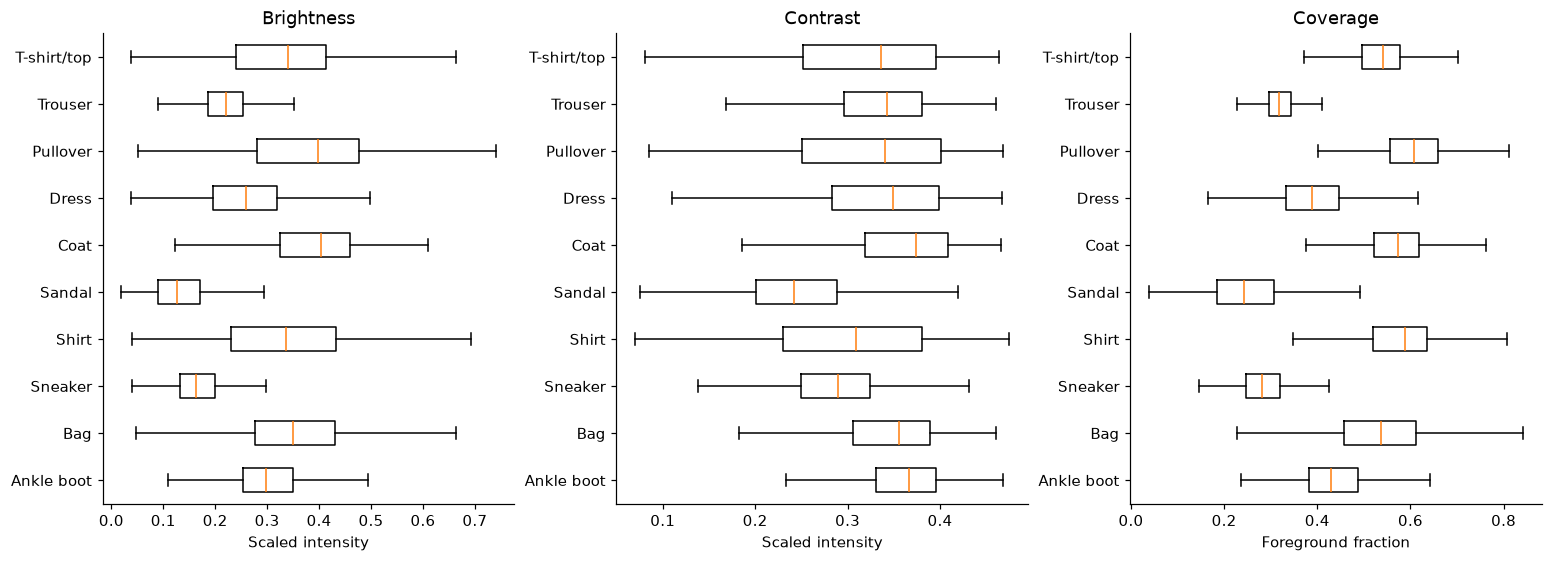

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), layout='constrained')
for ax, feature in zip(axes, ['Brightness', 'Contrast', 'Coverage']):
    groups = [features.loc[features['Class'] == name, feature] for name in NAMES]
    ax.boxplot(groups, orientation='horizontal', tick_labels=NAMES, showfliers=False)
    ax.set(title=feature, xlabel='Foreground fraction' if feature == 'Coverage' else 'Scaled intensity')
    ax.invert_yaxis()
plt.show()

**Observation and comment**

The class distributions overlap, so none of these single-number features cleanly identifies every category. Sandals occupy relatively little foreground area, whereas fuller garments cover more of the frame. Differences in median brightness can reflect silhouette and background as well as fabric appearance.

### 7.2 Inspect the extreme examples

For each feature, display the two lowest and two highest training examples.

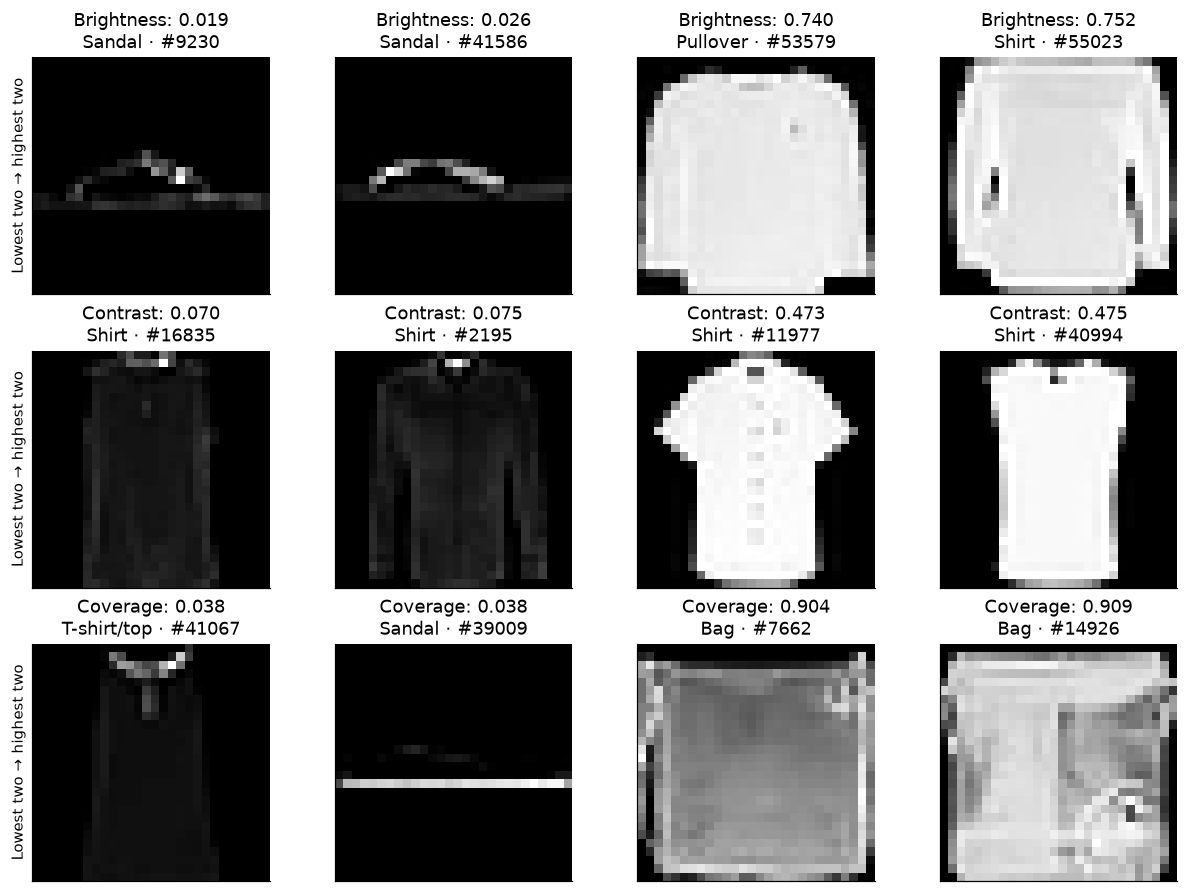

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(11, 8), layout='constrained')
for row, feature in enumerate(['Brightness', 'Contrast', 'Coverage']):
    ordered = features[feature].sort_values(kind='stable')
    chosen = list(ordered.index[:2]) + list(ordered.index[-2:])
    for col, index in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(X[index], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax.set(title=f'{feature}: {features.loc[index, feature]:.3f}\n{NAMES[y[index]]} · #{index}',
               xticks=[], yticks=[])
    axes[row, 0].set_ylabel('Lowest two → highest two')
plt.show()

**Observation and comment**

The lowest-brightness examples are dark sandals; the lowest-contrast examples are dark shirts. The two highest-coverage examples are bags that nearly fill the frame. Sandal #39009 has an unusual large bright region below the footwear, which deserves closer inspection before proposing a cleaning rule. These deliberately selected extremes are not representative examples or confirmed labeling errors.

### 7.3 What does the foreground threshold select?

Compare an image with its threshold mask.

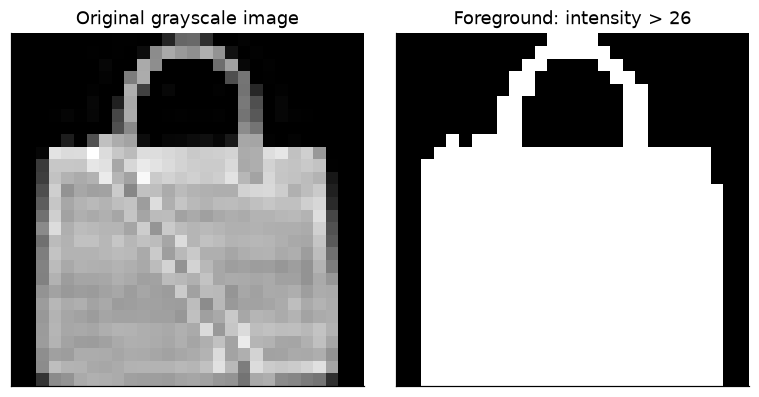

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), layout='constrained')
axes[0].imshow(example, cmap='gray', vmin=0, vmax=255)
axes[0].set(title='Original grayscale image', xticks=[], yticks=[])
axes[1].imshow(example > FOREGROUND_THRESHOLD, cmap='gray', vmin=0, vmax=1)
axes[1].set(title=f'Foreground: intensity > {FOREGROUND_THRESHOLD}', xticks=[], yticks=[])
plt.show()

**Observation and comment**

The mask simplifies the grayscale image into occupied and unoccupied pixels. It can exclude dark parts of the garment, so coverage is a threshold-based proxy rather than a precise segmentation. The original grayscale image remains the input representation.

### 7.4 Sensitivity to the foreground threshold

Change the threshold by ten intensity levels in either direction and compare median coverage by class.

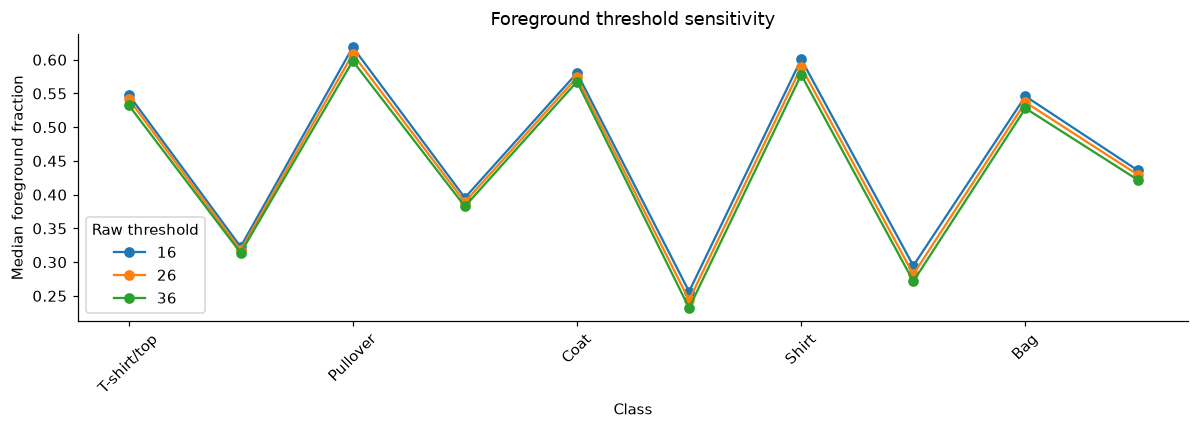

In [17]:
coverage_by_threshold = {}
for threshold in [16, 26, 36]:
    coverage = (train_images > threshold).mean(axis=(1, 2))
    coverage_by_threshold[threshold] = [np.median(coverage[train_labels == k]) for k in range(10)]
sensitivity = pd.DataFrame(coverage_by_threshold, index=NAMES)
ax = sensitivity.plot(marker='o', figsize=(11, 4), rot=45)
ax.set(xlabel='Class', ylabel='Median foreground fraction', title='Foreground threshold sensitivity')
ax.legend(title='Raw threshold')
plt.tight_layout()
plt.show()

**Observation and comment**

Increasing the threshold reduces measured foreground coverage. Compare the spacing and ordering of the curves before treating a class difference as robust. The thresholds describe the same unmodified images; they do not define alternative cleaned datasets.

## 8. Average appearance of each class

Average the training images within each class, using a shared grayscale range.

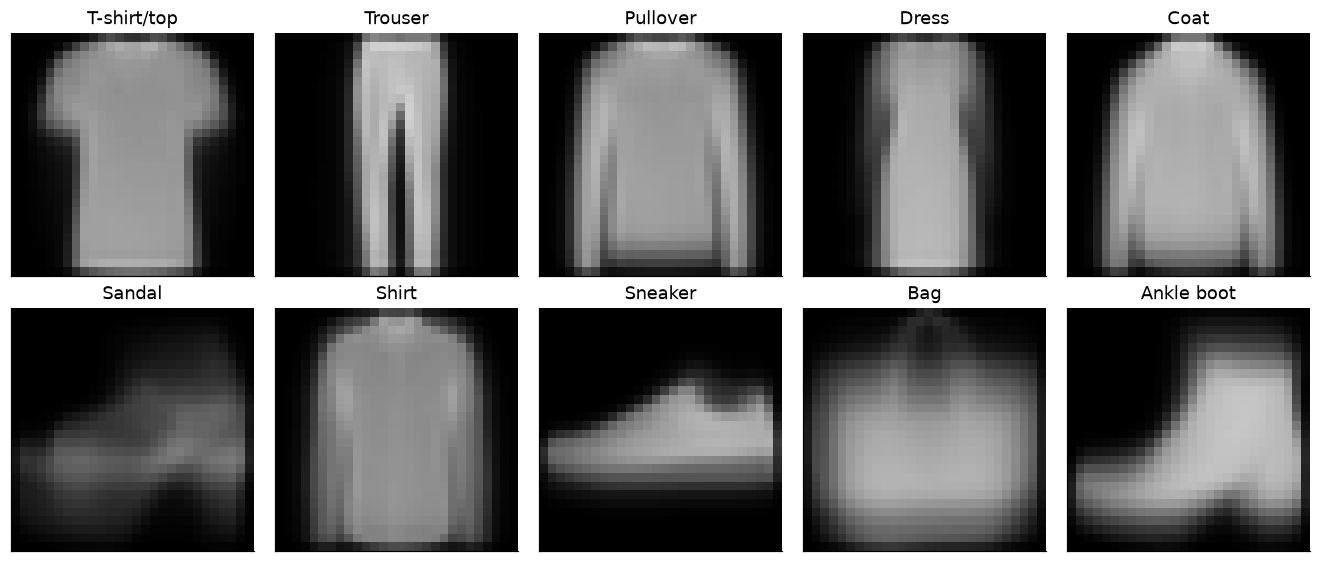

In [18]:
class_means = np.array([pixels[train_labels == k].mean(axis=0) for k in range(10)])
fig, axes = plt.subplots(2, 5, figsize=(12, 5), layout='constrained')
for label, ax in enumerate(axes.flat):
    ax.imshow(class_means[label], cmap='gray', vmin=0, vmax=1)
    ax.set(title=NAMES[label], xticks=[], yticks=[])
plt.show()

**Observation and comment**

Averaging preserves common silhouettes while blurring details and variations in pose. Trousers and footwear retain characteristic shapes; several upper-body categories have similar outlines. These are synthetic mean images, not actual products or representative individual examples.

### 8.1 Compare class means

Measure root-mean-square (RMS) distance between class means on the [0, 1] intensity scale.

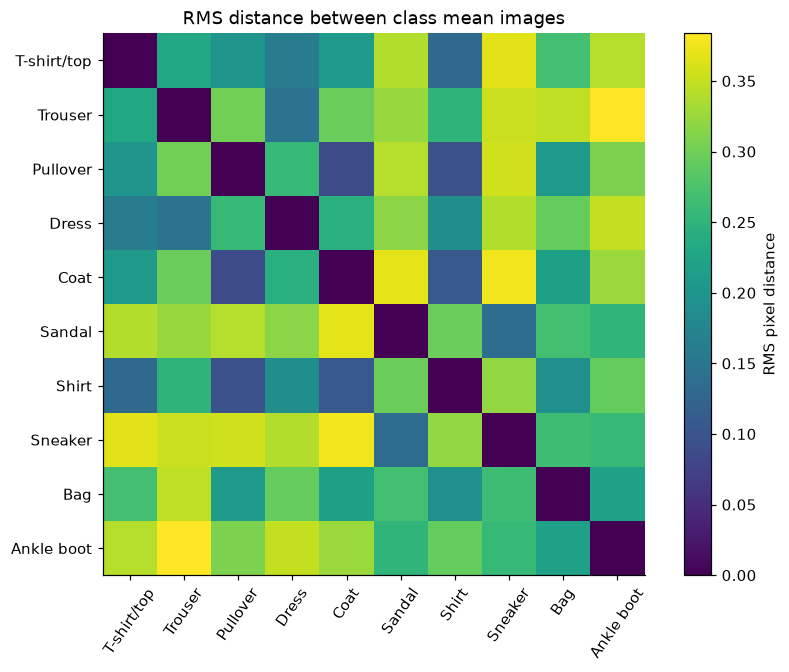

In [19]:
centroid_distance = np.sqrt(((class_means[:, None] - class_means[None, :]) ** 2).mean(axis=(2, 3)))
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')
image = ax.imshow(centroid_distance, cmap='viridis')
ax.set(xticks=range(10), yticks=range(10), xticklabels=NAMES, yticklabels=NAMES,
       title='RMS distance between class mean images')
ax.tick_params(axis='x', rotation=55)
fig.colorbar(image, ax=ax, label='RMS pixel distance')
plt.show()

**Observation and comment**

Dark off-diagonal cells indicate similar average appearances. This comparison suggests class pairs to inspect visually. It is not a confusion matrix: no classifier has been trained, and similarity between means does not measure prediction errors.

### 8.2 Which average silhouettes are closest?

List the five smallest distances between distinct classes.

In [20]:
left, right = np.triu_indices(10, k=1)
closest = np.argsort(centroid_distance[left, right])[:5]
pd.DataFrame({
    'Class A': [NAMES[left[i]] for i in closest],
    'Class B': [NAMES[right[i]] for i in closest],
    'RMS distance': centroid_distance[left[closest], right[closest]]
}).round(3)

,Class A,Class B,RMS distance
0,Pullover,Coat,0.088
1,Pullover,Shirt,0.096
2,Coat,Shirt,0.107
3,T-shirt/top,Shirt,0.132
4,Sandal,Sneaker,0.137


**Observation and comment**

Pullover and Coat have the closest mean images. Their similar torso-and-sleeve structure is consistent with the earlier galleries. This is a hypothesis about visual ambiguity; class means can hide substantial differences among individual images.

### 8.3 Return to real images of the closest pair

Use the previously sampled examples to compare the closest two classes directly.

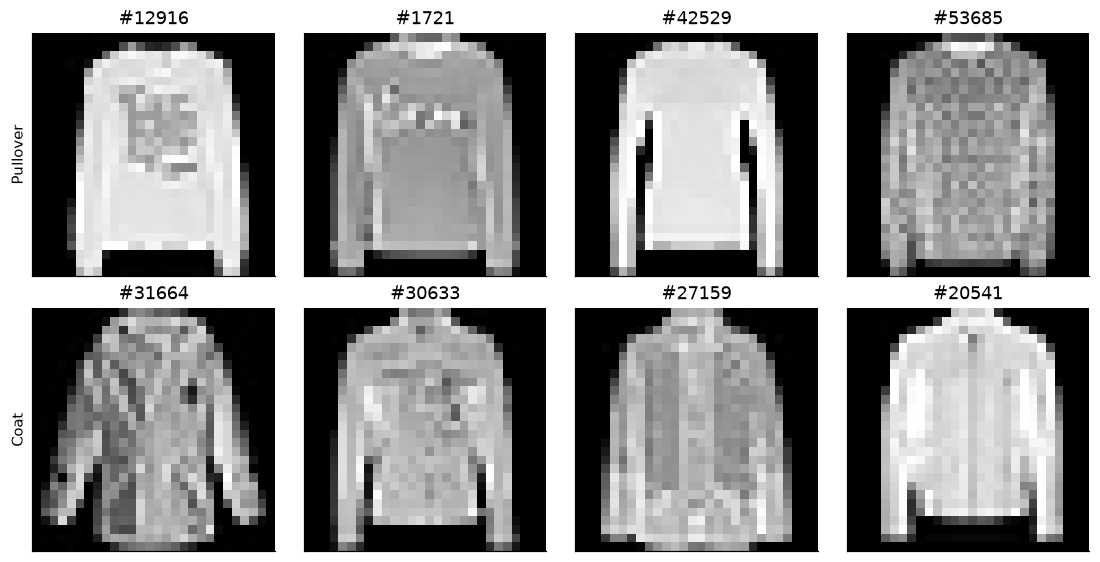

In [21]:
closest_labels = [int(left[closest[0]]), int(right[closest[0]])]
fig, axes = plt.subplots(2, 4, figsize=(10, 5), layout='constrained')
for row, label in enumerate(closest_labels):
    for ax, index in zip(axes[row], gallery_ids[label]):
        ax.imshow(X[index], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax.set(title=f'#{index}', xticks=[], yticks=[])
    axes[row, 0].set_ylabel(NAMES[label])
plt.show()

**Observation and comment**

The real examples show both shared silhouettes and differences that averaging smooths away. Necklines, openings, length and texture can matter, but they may be subtle at 28 × 28 resolution. Similarity in this small gallery does not imply that the categories are interchangeable.

## 9. PCA: how much variation fits in fewer dimensions?

Fit an exploratory projection on a balanced sample of 6,000 training images. PCA uses pixel variation, not labels; labels only define the balanced sample.

In [22]:
from sklearn.decomposition import PCA

pca_rng = np.random.default_rng(SEED)
pca_ids = np.concatenate([
    pca_rng.choice(train_idx[y[train_idx] == k], 600, replace=False) for k in range(10)])
pca_pixels = X[pca_ids].reshape(-1, 784).astype(np.float32) / 255
pca = PCA(n_components=128, svd_solver='randomized', random_state=SEED)
with threadpool_limits(limits=1):
    pca_scores = pca.fit_transform(pca_pixels)
explained = np.cumsum(pca.explained_variance_ratio_)
pd.DataFrame({'Components': [2, 8, 16, 32, 64, 128],
              'Cumulative variance (%)': 100 * explained[np.array([2, 8, 16, 32, 64, 128]) - 1]}).round(2)

,Components,Cumulative variance (%)
0,2,46.619999
1,8,69.239998
2,16,76.449997
3,32,82.610001
4,64,88.220001
5,128,92.940002


**Observation and comment**

Two components retain about 46.62% of the variation in this 6,000-image training sample; 64 retain 88.22%, and 128 retain 92.94%. A two-dimensional view therefore discards more than half the measured variation. Retained variance is different from the category-specific information needed for classification.

### 9.1 Cumulative explained variance

View the tradeoff between the number of components and retained variation.

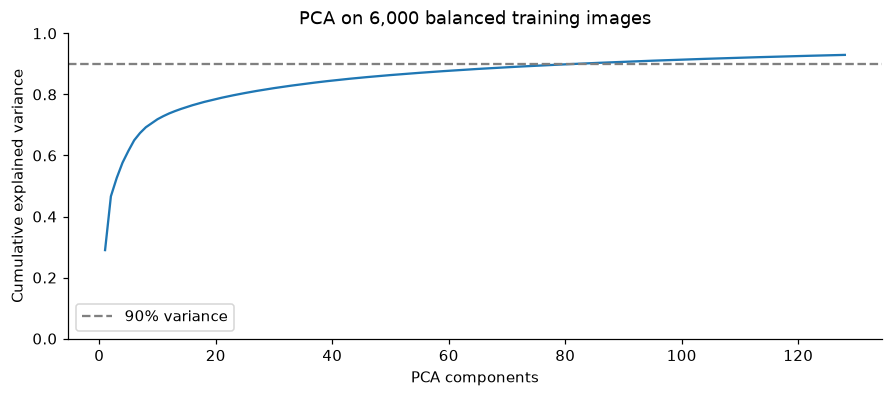

In [23]:
fig, ax = plt.subplots(figsize=(8, 3.5), layout='constrained')
ax.plot(np.arange(1, 129), explained)
ax.axhline(0.90, color='gray', linestyle='--', label='90% variance')
ax.set(xlabel='PCA components', ylabel='Cumulative explained variance', ylim=(0, 1),
       title='PCA on 6,000 balanced training images')
ax.legend()
plt.show()

**Observation and comment**

The curve rises quickly and then flattens: later components each add less variance. Only 128 components were computed, so targets above the endpoint cannot be assigned a component count from this run. A compression choice would need a separate evaluation of its effect on the eventual task.

### 9.2 Look at reconstructed images

Reconstruct one sampled image from each of four classes. Clip only the displayed intensities to [0, 1].

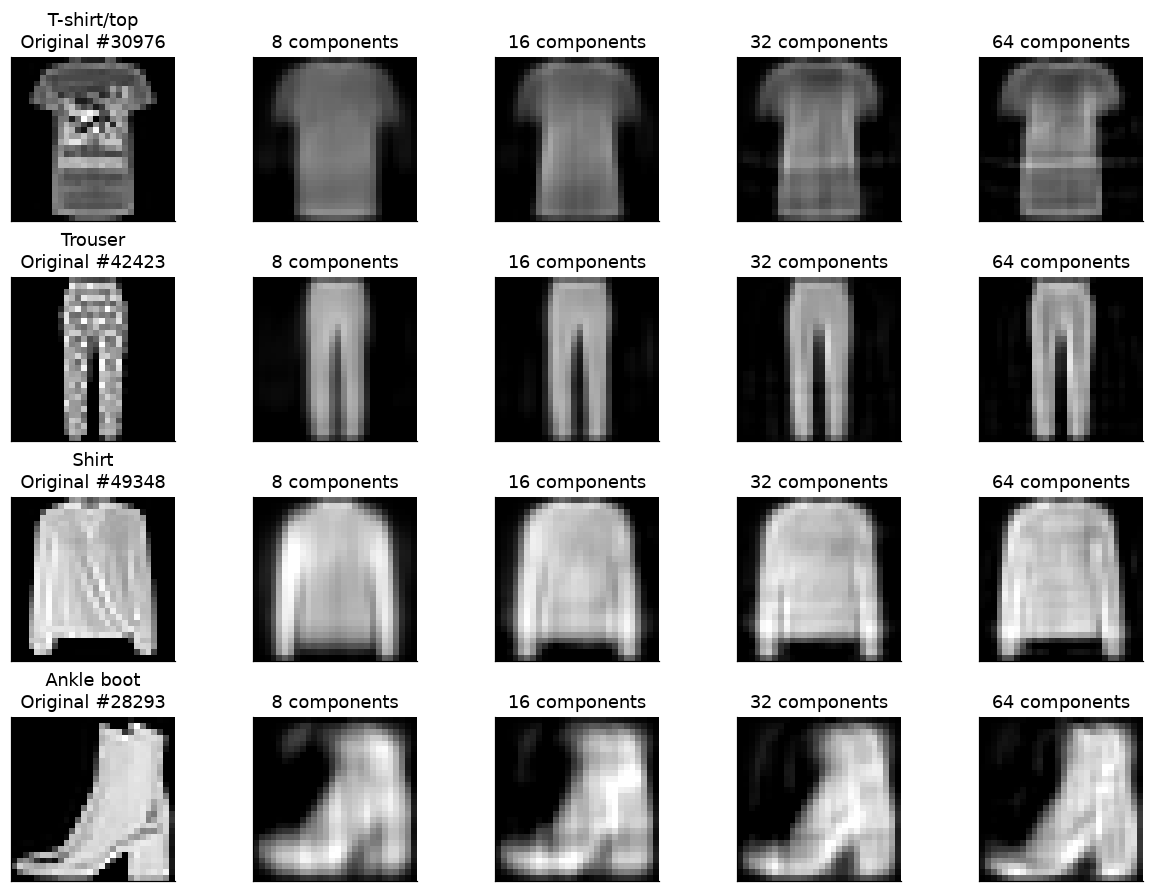

In [24]:
positions = [int(np.flatnonzero(y[pca_ids] == k)[0]) for k in [0, 1, 6, 9]]
ranks = [8, 16, 32, 64]
fig, axes = plt.subplots(4, 5, figsize=(11, 8), layout='constrained')
for row, position in enumerate(positions):
    axes[row, 0].imshow(pca_pixels[position].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'{NAMES[y[pca_ids[position]]]}\nOriginal #{pca_ids[position]}')
    for col, rank in enumerate(ranks, start=1):
        recovered = pca_scores[position, :rank] @ pca.components_[:rank] + pca.mean_
        axes[row, col].imshow(recovered.reshape(28, 28).clip(0, 1), cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_title(f'{rank} components')
    for ax in axes[row]:
        ax.set(xticks=[], yticks=[])
plt.show()

**Observation and comment**

Broad silhouettes are recognizable with eight components, while more components sharpen sleeves, trouser legs and the boot outline. The patterned trousers and printed T-shirt still lose fine detail at 64 components. These images belong to the PCA fitting sample and illustrate reconstruction; they do not estimate performance on unseen data.

## 10. Two-dimensional views of the same images

Select 200 images per class from the PCA sample and plot their first two component scores.

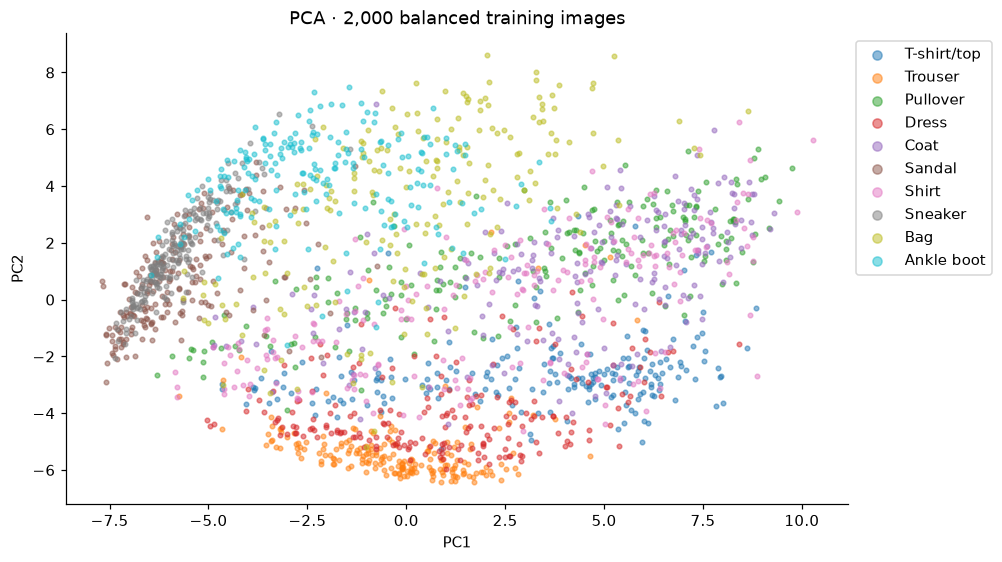

In [25]:
view_positions = np.concatenate([np.arange(k * 600, k * 600 + 200) for k in range(10)])
view_labels = y[pca_ids[view_positions]]
view_scores = pca_scores[view_positions]
colors = plt.get_cmap('tab10').colors
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
for label, name in enumerate(NAMES):
    points = view_scores[view_labels == label]
    ax.scatter(points[:, 0], points[:, 1], s=9, alpha=0.5, color=colors[label], label=name)
ax.set(title='PCA · 2,000 balanced training images', xlabel='PC1', ylabel='PC2')
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', markerscale=2)
plt.show()

**Observation and comment**

Several labels overlap in the first two components. PCA maximizes overall pixel variance, so its leading directions need not separate clothing classes. Overlap in this view does not show that the original 784-dimensional inputs are inseparable.

### 10.1 A nonlinear view with t-SNE

Embed the same 2,000 images using their first 50 PCA scores. This is an exploratory visualization, not classifier training.

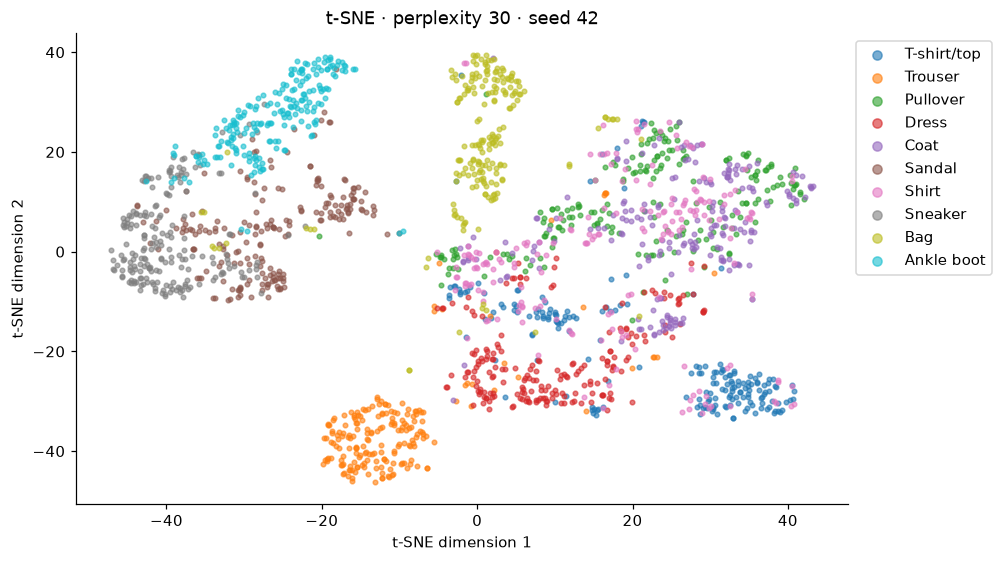

In [26]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, max_iter=750, init='pca',
            learning_rate='auto', random_state=SEED, n_jobs=1)
with threadpool_limits(limits=1):
    embedding = tsne.fit_transform(view_scores[:, :50])
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
for label, name in enumerate(NAMES):
    points = embedding[view_labels == label]
    ax.scatter(points[:, 0], points[:, 1], s=9, alpha=0.6, color=colors[label], label=name)
ax.set(title='t-SNE · perplexity 30 · seed 42', xlabel='t-SNE dimension 1', ylabel='t-SNE dimension 2')
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', markerscale=2)
plt.show()

**Observation and comment**

Trousers form a compact neighborhood, while many pullover, coat and shirt points mix in the upper-body clothing region. Footwear occupies another part of the view, with some sandal and sneaker mixing. These local patterns support further image inspection. Distances between distant groups, apparent gaps and cluster sizes are not classification accuracy or reliable global similarity measures; the layout depends on sampling and settings.

## 11. Inspect preprocessing

Calculate normalization statistics from the 54,000 training images only. Scaling divides by 255; standardization then subtracts the training mean and divides by its standard deviation.

In [27]:
levels = np.arange(256, dtype=np.float64) / 255
probabilities = pixel_counts / pixel_counts.sum()
mean = float(probabilities @ levels)
std = float(np.sqrt(probabilities @ ((levels - mean) ** 2)))
standardized_levels = (levels - mean) / std
pd.DataFrame([
    ['Raw', 255 * mean, 255 * std, 0, 255],
    ['Scaled', mean, std, 0, 1],
    ['Standardized', probabilities @ standardized_levels,
     np.sqrt(probabilities @ (standardized_levels ** 2)), -mean / std, (1 - mean) / std]
], columns=['Representation', 'Mean', 'Population std', 'Min', 'Max']).round(6)

,Representation,Mean,Population std,Min,Max
0,Raw,72.983297,90.055735,0.000000,255.000000
1,Scaled,0.286209,0.353160,0.000000,1.000000
2,Standardized,0.000000,1.000000,-0.810424,2.021156


**Observation and comment**

The training-fitted mean and standard deviation on the [0, 1] scale are approximately 0.286209 and 0.353160. Standardization gives zero mean and unit standard deviation over all training pixels together, not separately within each image. Any later validation or test transformation should reuse these training statistics.

### 11.1 The same image before and after scaling

Use corresponding display ranges to compare the same image in three numerical representations.

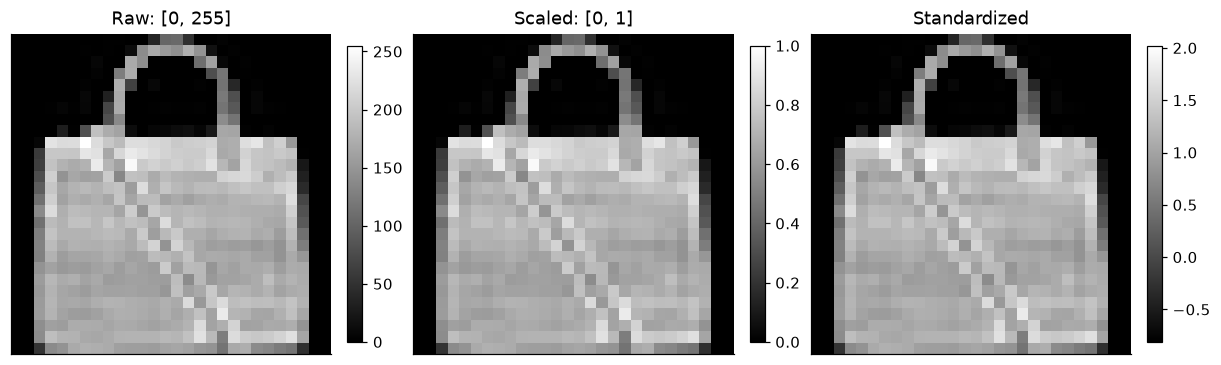

In [28]:
values = [example, example / 255, (example / 255 - mean) / std]
titles = ['Raw: [0, 255]', 'Scaled: [0, 1]', 'Standardized']
limits = [(0, 255), (0, 1), (-mean / std, (1 - mean) / std)]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), layout='constrained')
for ax, data, title, (low, high) in zip(axes, values, titles, limits):
    image = ax.imshow(data, cmap='gray', vmin=low, vmax=high)
    ax.set(title=title, xticks=[], yticks=[])
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

**Observation and comment**

The silhouettes remain identical because these transformations change numerical scale while preserving pixel order and relative contrast. The color bars show that the underlying values differ. Standardization includes negative values and is not restricted to [0, 1].

## 12. EDA conclusions

| Evidence from the exploration | Implication |
|---|---|
| Ten equally frequent classes in the original sets and stratified subsets | Start from an unweighted baseline; inspect class-specific performance later. |
| Fixed 28 × 28 grayscale images | Keep native resolution; a flattened image contains 784 values. |
| Large background regions and varied foreground intensities | Scaling is useful; zero pixels alone are not a reason to reject an image. |
| Broad brightness and coverage distributions within classes | Inspect unusual examples visually before proposing cleaning rules. |
| Pullover and Coat have similar mean silhouettes | Treat related upper-body categories as a hypothesis for later error analysis. |
| Two-dimensional projections discard information and mix some labels | Use them for exploration, not as an estimate of classifier performance. |
| Normalization statistics are calculated from training pixels only | Reuse the same mean and standard deviation for later validation and test inputs. |

**Limits.** The galleries are small samples. Pixel distances and threshold masks
describe appearance, not product identity or labeling correctness. PCA and t-SNE
are sample-based exploratory views. This notebook provides no classification
accuracy or evidence about which trained model is best.

**Handoff.** Separate training code can reproduce the split using seed 42,
`test_size=0.10` and `stratify=y`, and compute normalization on that training subset.
The EDA supports keeping all images and all pixel coordinates for an initial baseline.

### Sources

- [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist), Xiao et al. (2017), MIT license.
- [Fashion-MNIST paper](https://arxiv.org/abs/1708.07747).
- Course handbook and foundation slides: dataset description, preprocessing and exploratory analysis.